«Умное турагентство» 

Топология: Оркестратор и исполнители

Суть задачи: Пользователь дает промпт: "Спланируй отпуск в Токио на 5 дней в марте, найди билеты и отель". Система должна выдать готовый план с вариантами размещения и перелетов. 

Спецификация агентов агентов:
1) Supervisor (Оркестратор): Принимает запрос, разбивает его на подзадачи и делегирует их.
2) Destination Agent: Ищет информацию о достопримечательностях и составляет маршрут по дням.
3) Flight Agent: Ищет авиабилеты на заданные даты (можно использовать mock-API или поиск).
4) Hotel Agent: Подбирает варианты проживания. 

Почему здесь нужна МАС: Если дать все инструменты (поиск билетов, поиск отелей, сбор достопримечательностей) одному агенту, он может запутаться в вызовах или начать галлюцинировать из-за обилия данных. 
Изоляция контекста позволяет каждому сабагенту работать только со своим узким набором данных и инструментов, а супервизору - просто собрать итоговый результат.

In [1]:
import os
os.chdir('../../../')
os.getcwd()

'/Users/volzock/it/python/jupyter_root/MemoryAndMasHomework'

In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from src.travel_agency.core.environment import Environment
from src.travel_agency.core.llm import LLMFactory

In [4]:
llm = LLMFactory.get_llm()
llm_without_thinking = LLMFactory.get_llm(required_new=True, extra_body={"thinking": {"type": "disabled"}})

In [5]:
from src.travel_agency.tools import langchain_tools

In [7]:
all_tools = langchain_tools()
all_tools

{'search_flights': StructuredTool(name='search_flights', description='Search flights by city/IATA, optional date (YYYY-MM-DD), cabin\n(economy|premium_economy|business), price cap and direct_only flag.', args_schema=<class 'langchain_core.utils.pydantic.search_flights'>, func=<function langchain_tools.<locals>.search_flights at 0x10e5c0540>),
 'get_flight_details': StructuredTool(name='get_flight_details', description='Full fare card for a flight_id returned by search_flights.', args_schema=<class 'langchain_core.utils.pydantic.get_flight_details'>, func=<function langchain_tools.<locals>.get_flight_details at 0x10a344680>),
 'search_hotels': StructuredTool(name='search_hotels', description='Search hotels; filters: district, stars, nightly price cap,\nbreakfast, family friendliness.', args_schema=<class 'langchain_core.utils.pydantic.search_hotels'>, func=<function langchain_tools.<locals>.search_hotels at 0x10e392b60>),
 'get_hotel_details': StructuredTool(name='get_hotel_details', de

In [8]:
from typing import List
from langchain_core.tools import StructuredTool

In [9]:
def get_tools_by_names(names: List[str]) -> List[StructuredTool]:
    return [tool for tool_name, tool in all_tools.items() if tool_name in names]

In [10]:
from langchain_core.messages import HumanMessage

In [11]:
def run_with_print(graph, request: str, config) -> None:
    app_input = dict(messages=[HumanMessage(request)])
    for event in graph.stream(app_input, stream_mode="updates", config=config):
        key = list(event.keys())[0]
        if event[key]:
            event[key]["messages"][0].pretty_print()

In [12]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [13]:
base_config = {"configurable": {"thread_id": "user_session_123"}}

### Build *destination agent*

In [15]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.agents import create_agent

In [16]:
destination_agent_tools = get_tools_by_names(["get_attraction_details", "search_attractions"])

In [17]:
destination_agent_llm = llm.bind_tools(destination_agent_tools)

In [18]:
destination_agent_prompt = """
You are the expirienced traveler. You need to create the plan of the travel of our user. Create plan in any case!

First you need to get information from search_attractions. After use these information search more info by get_attraction_details and write the best plan what you can!
"""

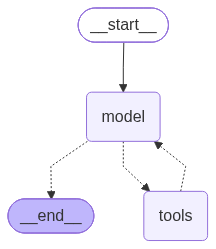

In [19]:
destination_agent = create_agent(destination_agent_llm, tools=destination_agent_tools, system_prompt=destination_agent_prompt, checkpointer=checkpointer)
destination_agent

In [20]:
run_with_print(destination_agent, "Я хочу поездить по Японии, помоги мне!", base_config)

================================== Ai Message ==================================

Отличная идея! Япония — потрясающая страна. Из доступных мне городов я могу помочь вам с **Токио**. Давайте я соберу информацию о самых интересных местах и составлю для вас план!

Начну с поиска по разным категориям:
Tool Calls:
  search_attractions (call_00_pt53jS3yEazbOBtRmsZb9855)
 Call ID: call_00_pt53jS3yEazbOBtRmsZb9855
  Args:
    city: Tokyo
    category: sights
  search_attractions (call_01_OaQtSWbT6zWtzi4dOrFe7836)
 Call ID: call_01_OaQtSWbT6zWtzi4dOrFe7836
  Args:
    city: Tokyo
    category: museums
  search_attractions (call_02_Y1EQHCHeSRLXoDUYwRW36517)
 Call ID: call_02_Y1EQHCHeSRLXoDUYwRW36517
  Args:
    city: Tokyo
    category: food
  search_attractions (call_03_7oe0rahZoaZ4jxgjMMHA1227)
 Call ID: call_03_7oe0rahZoaZ4jxgjMMHA1227
  Args:
    city: Tokyo
    category: parks
================================= Tool Message =================================
Name: search_attractions

[]
=====

---

# Часть 2. MAS с HITL — минимальная версия

```
supervisor (единственный checkpointer)
├─ plan_destination → search_attractions / get_attraction_details
├─ handle_flights   → search_flights  →  book_flight     ⏸ пауза
├─ handle_hotels    → search_hotels   →  book_hotel      ⏸ пауза
└─ handle_support   → cancel_booking                     ⏸ пауза
```

Три правила: мидлварь HITL вешается на саб-агента, которому принадлежит опасный инструмент; `checkpointer` только у супервизора (прерывание всплывает наверх само); поиск помечается `False`, чтобы не дёргать человека на чтении.

## 2.1. Запуск и обработка HITL

In [21]:
from langgraph.types import Command


def text_of(msg):
    t = getattr(msg, "text", None)
    return t() if callable(t) else (t or msg.content)

## 2.2. Сборка MAS

In [45]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

T = all_tools
hitl = lambda cfg: [HumanInTheLoopMiddleware(interrupt_on=cfg)]

destination = create_agent(
    llm, tools=[T["search_attractions"], T["get_attraction_details"]],
    system_prompt="Составь маршрут по дням. В последнем сообщении — весь план целиком.")

flights = create_agent(
    llm, tools=[T["search_flights"], T["get_flight_details"], T["book_flight"]],
    system_prompt="Подбери рейс, затем забронируй. В последнем сообщении — детали брони.",
    middleware=hitl({"search_flights": False, "get_flight_details": False,
                     "book_flight": True}))

hotels = create_agent(
    llm, tools=[T["search_hotels"], T["get_hotel_details"], T["book_hotel"]],
    system_prompt="Подбери отель, затем забронируй. В последнем сообщении — детали брони.",
    middleware=hitl({"search_hotels": False, "get_hotel_details": False,
                     "book_hotel": True}))

support = create_agent(
    llm, tools=[T["cancel_booking"]],
    system_prompt="Отменяй брони по PNR. В последнем сообщении — результат.",
    middleware=hitl({"cancel_booking": {"allowed_decisions": ["approve", "reject"]}}))


def as_tool(agent, name, description):
    @tool(name, description=description)
    def run(request: str) -> str:
        out = agent.invoke({"messages": [{"role": "user", "content": request}]})
        return text_of(out["messages"][-1])
    return run


supervisor = create_agent(
    llm,
    tools=[
        as_tool(destination, "plan_destination", "Маршрут и достопримечательности."),
        as_tool(flights, "handle_flights", "Подбор и бронирование авиабилетов."),
        as_tool(hotels, "handle_hotels", "Подбор и бронирование отеля."),
        as_tool(support, "handle_support", "Отмена брони по PNR."),
    ],
    system_prompt="Ты координатор турагентства. Разбей запрос на подзадачи и делегируй их.",
    checkpointer=InMemorySaver(),
)

## 2.3. Тест

Проверяем главное: до решения человека бронирование **не выполняется**, а после `approve` — выполняется.

In [46]:
config = {"configurable": {"thread_id": "trip-001"}}

In [48]:
result = supervisor.invoke(
    {"messages": [{
        "role": "user",
        "content": "Теперь найди рейс Москва — Токие на 14 марта, "
                   "и забронируй самый дешёвый вариант."
                   "Мой номер телефона +7(999)555-44-44, Паспорт РФ: '1234 567890' и почта gmail@gmail.com"
    }]},
    config,
)

/var/folders/1_/crk7lt655_d32d839p2_lk140000gn/T/ipykernel_35188/3049906195.py:35: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  return text_of(out["messages"][-1])


In [53]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Вот что удалось найти. Но есть важный нюанс: в системе доступны рейсы только на **14 марта 2026 года** — на 2025 год предложений, к сожалению, нет.

---

### 🥇 Самый дешёвый вариант — **$612**

| Параметр | Детали |
|---|---|
| **Рейс** | FL-CZ0656 |
| **Авиакомпания** | China Southern |
| **Маршрут** | Москва (SVO) → Гуанчжоу (CAN) → Токио (NRT) |
| **Вылет** | 14 марта 2026, 18:55 |
| **Прилёт** | 16 марта 2026, 08:40 |
| **Длительность** | ~25 ч 45 мин |
| **Пересадка** | Гуанчжоу, 6 ч 20 мин |
| **Класс** | Эконом |
| **Багаж** | 23 кг |
| **Возврат** | ❌ Невозвратный |
| **Осталось мест** | 38 |

---

Для сравнения, второй вариант — Air China через Пекин за **$698** (быстрее, ~18 часов).

**Главный вопрос:** устраивает ли тебя дата — **14 марта 2026**, а не 2025? Если да, я сразу бронирую самый дешёвый FL-CZ0656 за $612 с твоими данными. Подтверждаешь?


In [54]:
result = supervisor.invoke(
    {"messages": [{
        "role": "user",
        "content": "Ага устраивает!"
    }]},
    config,
)

/var/folders/1_/crk7lt655_d32d839p2_lk140000gn/T/ipykernel_35188/3049906195.py:35: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  return text_of(out["messages"][-1])


In [56]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Почти готово! Но система требует ещё одно поле — **твои полные ФИО** (как в загранпаспорте).

Вот что у меня уже есть:

| Данные | Значение |
|---|---|
| **Телефон** | +7(999)555-44-44 |
| **Паспорт РФ** | 1234 567890 |
| **Email** | gmail@gmail.com |
| **Рейс** | FL-CZ0656, SVO → NRT |
| **Дата** | 14 марта 2026 |
| **Цена** | $612 |

❓ Осталось только — **напиши своё полное имя (ФИО)**, и я сразу завершу бронирование!


In [57]:
result = supervisor.invoke(
    {"messages": [{
        "role": "user",
        "content": "мое фио это ЗУБЕНКО МИХАИЛ ПЕТРОВИЧ"
    }]},
    config,
)

/var/folders/1_/crk7lt655_d32d839p2_lk140000gn/T/ipykernel_35188/3049906195.py:35: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  return text_of(out["messages"][-1])


In [58]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Всё собрано, осталось финальное подтверждение. Данные проверены:

| ✈️ **Рейс FL-CZ0656** | |
|---|---|
| **Маршрут** | Москва (SVO) → Токио (NRT) |
| **Вылет** | 14 марта 2026, 18:55 |
| **Прилёт** | 16 марта 2026, 08:40 |
| **Пересадка** | Гуанчжоу, 6 ч 20 мин |
| **Цена** | **$612** |
| **Багаж** | 23 кг |
| **Пассажир** | Зубенко Михаил Петрович |

⚠️ Бронирование необратимо. Ты уже говорил «устраивает» — но дай финальное **«да»** или **«подтверждаю»**, и я завершу бронь!


In [60]:
result = supervisor.invoke(
    {"messages": [{
        "role": "user",
        "content": "Давай!"
    }]},
    config,
)

In [61]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Поехали! Финальное подтверждение.
Tool Calls:
  handle_flights (call_00_nyrEqvcGpICtlg61BKPG2005)
 Call ID: call_00_nyrEqvcGpICtlg61BKPG2005
  Args:
    request: Подтверждаю бронирование рейса FL-CZ0656. Пассажир: Зубенко Михаил Петрович. Данные: паспорт РФ 1234 567890, телефон +7(999)555-44-44, email gmail@gmail.com. Бронировать.


In [63]:
result["__interrupt__"]

[Interrupt(value={'action_requests': [{'name': 'book_flight', 'args': {'flight_id': 'FL-CZ0656', 'full_name': 'Зубенко Михаил Петрович', 'email': 'gmail@gmail.com', 'passport': '1234 567890', 'idempotency_key': 'FL-CZ0656-ZubenkoMP-1234567890'}, 'description': "Tool execution requires approval\n\nTool: book_flight\nArgs: {'flight_id': 'FL-CZ0656', 'full_name': 'Зубенко Михаил Петрович', 'email': 'gmail@gmail.com', 'passport': '1234 567890', 'idempotency_key': 'FL-CZ0656-ZubenkoMP-1234567890'}"}], 'review_configs': [{'action_name': 'book_flight', 'allowed_decisions': ['approve', 'edit', 'reject', 'respond']}]}, id='9aa5ceabcb6e10816e402c98b01a06c5')]

In [62]:
for intr in result["__interrupt__"]:
    print("interrupt id:", intr.id)
    for req in intr.value:          # value — список запросов (по одному на тул-колл)
        print(req)

interrupt id: 9aa5ceabcb6e10816e402c98b01a06c5
action_requests
review_configs


In [64]:
result = supervisor.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config,
)

/var/folders/1_/crk7lt655_d32d839p2_lk140000gn/T/ipykernel_35188/3049906195.py:35: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  return text_of(out["messages"][-1])


In [65]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

Готово! ✅

---

### 🎫 Бронь подтверждена!

| Параметр | Значение |
|---|---|
| **PNR** | **FB96949** |
| **Пассажир** | Зубенко Михаил Петрович |
| **Рейс** | CZ656 + CZ385 (China Southern) |
| **Маршрут** | Москва (SVO) → Токио (NRT) |
| **Вылет** | 14 марта 2026, 18:55 |
| **Прилёт** | 16 марта 2026, 08:40 |
| **Пересадка** | Гуанчжоу, 6 ч 20 мин |
| **Класс** | Эконом |
| **Багаж** | 23 кг |
| **Цена** | **$612** |
| **Статус** | ✅ Подтверждено |

---

Вся информация отправлена на **gmail@gmail.com**. Сохрани PNR **FB96949** — он пригодится для регистрации и любых изменений.

Счастливого пути, Михаил Петрович! 🛫🌸
